<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

# Notebook 1
### This notebook accompanies slide set 1.

In [ ]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

  Cloning https://github.com/dnepple/tprstats-python (to revision colab) to /tmp/pip-req-build-1609zblf
  Running command git clone --filter=blob:none --quiet https://github.com/dnepple/tprstats-python /tmp/pip-req-build-1609zblf
  Running command git checkout -b colab --track origin/colab
  Switched to a new branch 'colab'
  Branch 'colab' set up to track remote branch 'colab' from 'origin'.
  Resolved https://github.com/dnepple/tprstats-python to commit d5b7ac1c19bfee3ed707aefeeb1cbc04ba8934ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.0 MB/s eta 0:00:00
  Created wheel for tprstats: filename=tprstats-0.1.0-py3-none-any.whl size=11433 sha256=e38399a69178cc4de2bccb588e13689ac49ea560fcd08e774bb7d0755111c884
  Stored in directory: /tmp/pip-ephem-wheel-cache-k7ct1l8f/wheels/5d/0e/3a/ef7ae3e58a9bf61b5c91546d764aaf5ac5df485b9ce38295fe
Succ

In [ ]:
 # import the google drive package
from google.colab import drive
# mount google drive
drive.mount('/content/drive')
# set the working directory to the course folder. SDM is an abbreviation of Statistical Decision Making.
%cd '/content/drive/MyDrive/SDM'

Mounted at /content/drive
/content/drive/MyDrive/SDM


In [ ]:
%precision %.4f
import pandas
import matplotlib.pyplot as plt
import numpy
from scipy.stats import norm, t, uniform
numpy.random.seed(93408)

## Review of Hypothesis Testing

In [ ]:
# Calculate .975 Quantile of t-distribution with 29 degrees of freedom
t.ppf(.975, 29)   # 29 degrees of freedom

np.float64(2.045229642132703)

In [ ]:
# Calculate two-tailed p-value when t=-1.205 and df = 29
2 * t.cdf(-1.205, 29)

np.float64(0.2379448673915429)

In [ ]:
 # import Data
Call_Center_Data = pandas.read_excel("data/Call_Center_Data.xlsx")
Dollar_Bank = pandas.read_excel("data/Dollar_Bank.xlsx")
Dice_Data=pandas.read_excel("data/Dice_Data.xlsx")
Pgh_May_Temps = pandas.read_excel("data/Pgh_May_Temps.xlsx")
Theta_data = pandas.read_excel("data/Theta_data.xlsx")
Defects_data = pandas.read_excel("data/Defects_data.xlsx")
Diamonds_17_data = pandas.read_excel("data/Diamonds_17.xlsx")

In [ ]:
# Conduct the hypothesis test that population mean travel time to Dollar Bank is 15
tprstats.test_population_mean(Dollar_Bank["TVL"], 15)

,0
t_statistic,-1.205073
p_value,0.237917
confidence_interval_lower,12.033099
confidence_interval_upper,15.766901
sample_mean,13.900000


In [ ]:
# Conduct the hypothesis test that population mean=3.5
tprstats.test_population_mean(Dice_Data["X"], 3.5)

,0
t_statistic,-2.535983
p_value,0.016859
confidence_interval_lower,2.416110
confidence_interval_upper,3.383890
sample_mean,2.900000


In [ ]:
# Calculate two-tailed p-value
# The slight difference between p-value below and just above is because
# t-stat below is -2.53 whereas t-stat above has more digits after decimal point
2 * t.cdf(-2.53, 29)

np.float64(0.01709485042271036)

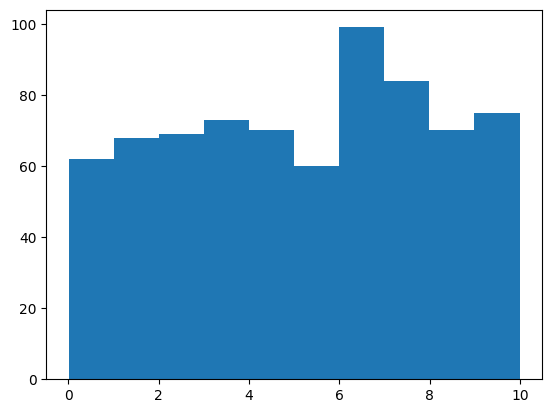

In [ ]:
# Draw a sample of size 730 from the uniform distribution on the interval from 0 to 10 and name the result xu.
xu = uniform.rvs(0, 10, 730)
# Plot and view historgram of data
plt.hist(xu)
plt.show()

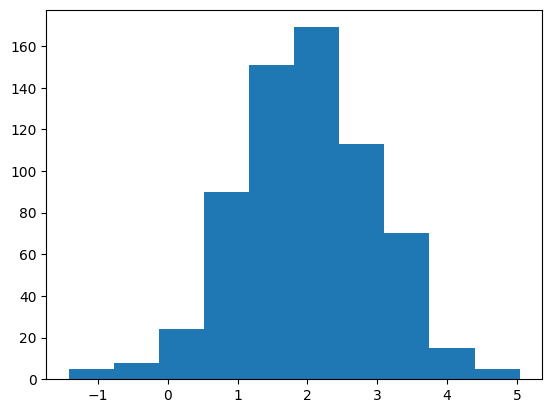

In [ ]:
# Draw a sample of size 650 from normal distribution with mean 2 and std dev 1
xn = norm.rvs(2, 1, 650)
plt.hist(xn)
plt.show()

## Slides: Understanding and Calculating Quantiles

In [ ]:
# Calculate .975 quantile of normal distribution
norm.ppf(0.975)

np.float64(1.959963984540054)

In [ ]:
# Calculate the .975 quantile of the t-distribution with 12 df
t.ppf(0.975, 12)

np.float64(2.1788128296634177)

In [ ]:
# View 75th quantile of Pittsburgh may Temperatures
Pgh_May_Temps["Temperature"].quantile(0.75)

np.float64(67.875)

In [ ]:
# Calculate the 10th, 50th, and 90th quantiles
Pgh_May_Temps["Temperature"].quantile([0.10, 0.5, 0.90])

,Temperature
0.1,51.20
0.5,61.60
0.9,72.97


## Slides: Statistical Quality Control

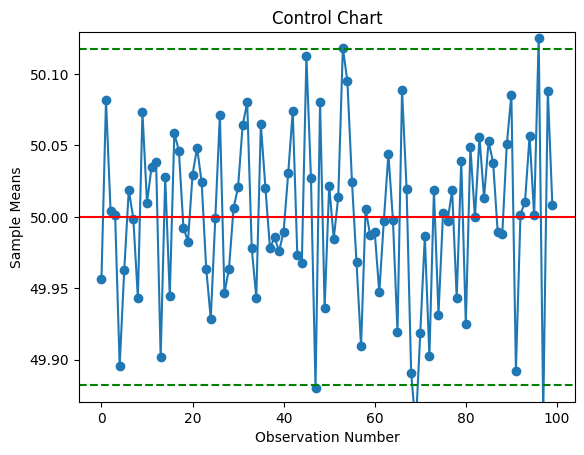

In [ ]:
# Following plots control chart for XBAR Theta & Theta Candy
tprstats.control_chart(mu=50, sig=0.3, n=25, alpha=0.05, data=Theta_data["XBAR"])

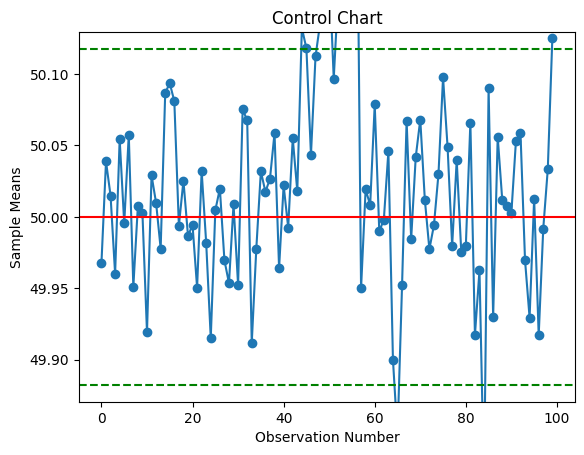

In [ ]:
# Following plots control chart for XBAR2 Theta & Theta Candy
# with alpha=.05
tprstats.control_chart(mu=50, sig=0.3, n=25, alpha=0.05, data=Theta_data["XBAR2"])

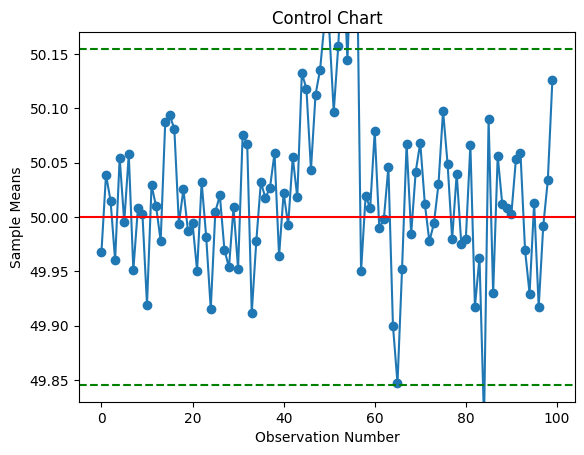

In [ ]:
# with alpha=.01
tprstats.control_chart(mu=50, sig=0.3, n=25, alpha=0.01, data=Theta_data["XBAR2"])

## Slides: Statistical Quality Control for Binary Outcomes

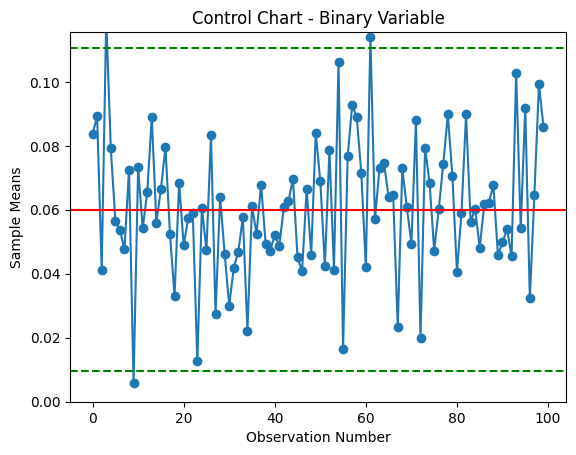

In [ ]:
# Following plots the control chart for defect rate d_rate
tprstats.control_chart_binary(p=0.06, n=85, alpha=0.05, data=Defects_data["d_rate"])

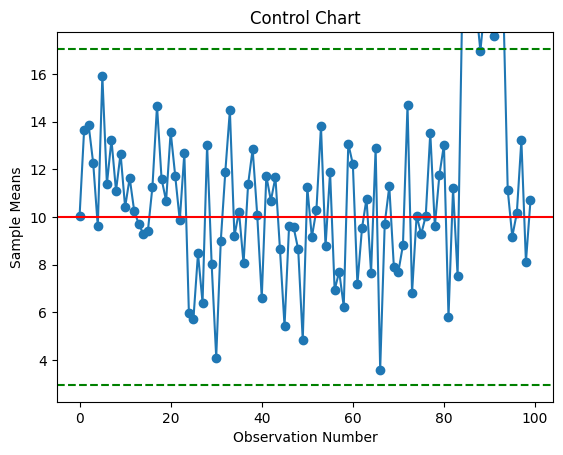

In [ ]:
# Following plots the control chart for Netflux call center
tprstats.control_chart(mu=10, sig=15, n=30, alpha=0.01, data=Call_Center_Data["WBAR"])